In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mticker
from linearmodels.iv import IV2SLS
import glob

In [2]:
files = glob.glob('../HW4/data/output/data-*.csv')
data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

Question 1

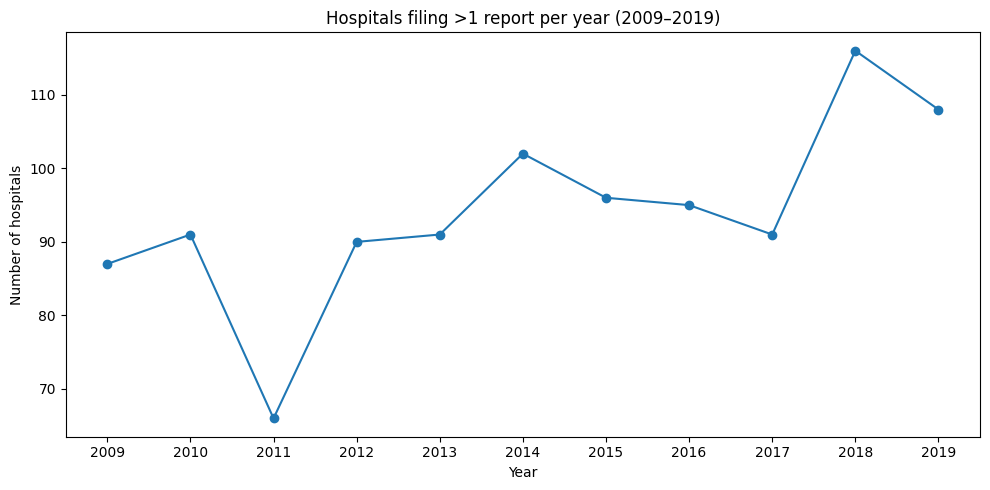

    year  hospitals
0   2009         87
1   2010         91
2   2011         66
3   2012         90
4   2013         91
5   2014        102
6   2015         96
7   2016         95
8   2017         91
9   2018        116
10  2019        108


In [3]:
#Question 1
df = data[data['year'].between(2009, 2019)]

result = (
    df[df['source'] != 'unique reports']
    .groupby('year')['provider_number']
    .nunique()
    .reset_index(name='hospitals')
)

plt.figure(figsize=(10, 5))
plt.plot(result['year'], result['hospitals'], marker='o')
plt.title('Hospitals filing >1 report per year (2009–2019)')
plt.xlabel('Year'); plt.ylabel('Number of hospitals')
plt.xticks(result['year'])
plt.tight_layout(); plt.show()
print(result)

Question 2

In [4]:
#Question 2

# Unique hospital IDs per year 
result = (df.groupby('year')['provider_number']
            .nunique()
            .reset_index(name='unique_hospitals'))

result.loc[len(result)] = ['Total', df['provider_number'].nunique()]

print(result.to_string(index=False))

 year  unique_hospitals
 2009              6100
 2010              6103
 2011              6097
 2012              6140
 2013              6066
 2014              6064
 2015              6051
 2016              6091
 2017              6083
 2018              6042
 2019              6035
Total              6897


Question 3

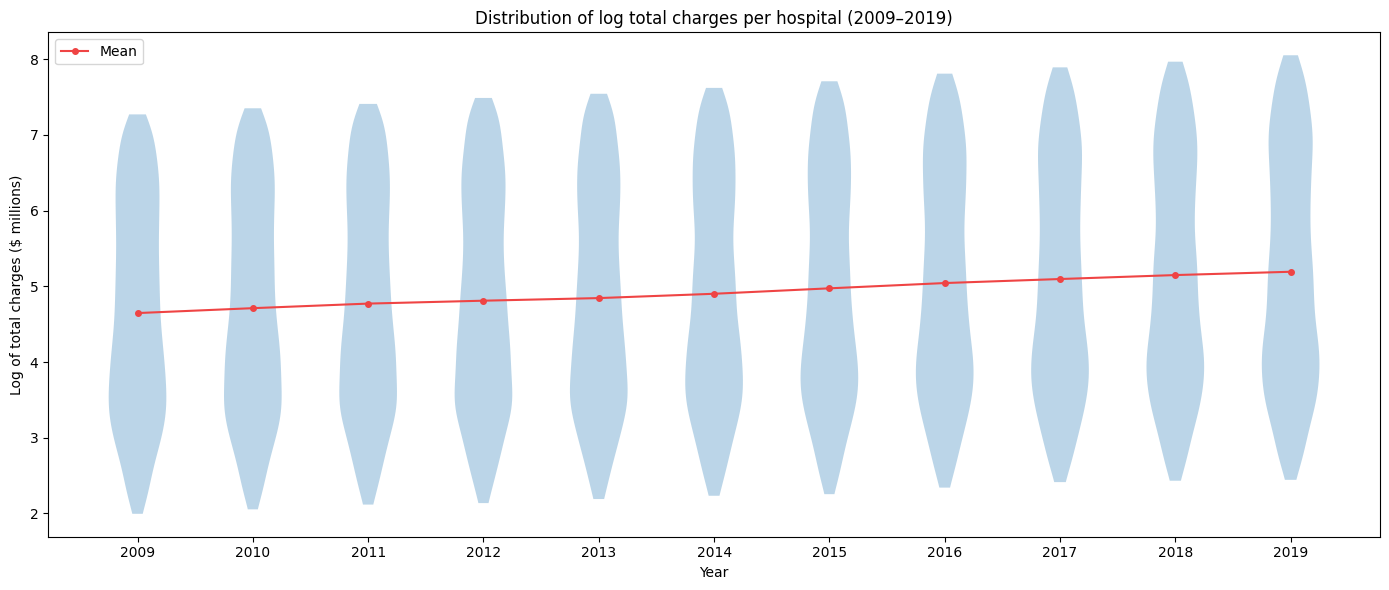

In [15]:
#Question 3 

years = sorted(df['year'].unique())
charges_data = []
for yr in years:
    d = df[df['year']==yr]['tot_charges'].dropna()
    lo  = d.quantile(0.05)          # remove bottom 5%
    cap = d.quantile(0.95)          # remove top 5%
    charges_data.append(np.log(d[(d >= lo) & (d <= cap)].values / 1e6))

fig, ax = plt.subplots(figsize=(14, 6))
parts = ax.violinplot(charges_data, positions=list(range(len(years))),
                      showmedians=False, showextrema=False)

 
means = [np.mean(arr) for arr in charges_data]
ax.plot(range(len(years)), means, color='#ef4444', linewidth=1.5,
        marker='o', markersize=4, label='Mean')

ax.legend(fontsize=10)
ax.set_xticks(range(len(years))); ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('Log of total charges ($ millions)')
ax.set_title('Distribution of log total charges per hospital (2009–2019)')
plt.tight_layout()
plt.savefig('q1_charges_violin.png', dpi=150)
plt.show()

Question 4

/tmp/ipykernel_1570407/894156393.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df4 = df4.groupby('year', group_keys=False).apply(remove_outliers)


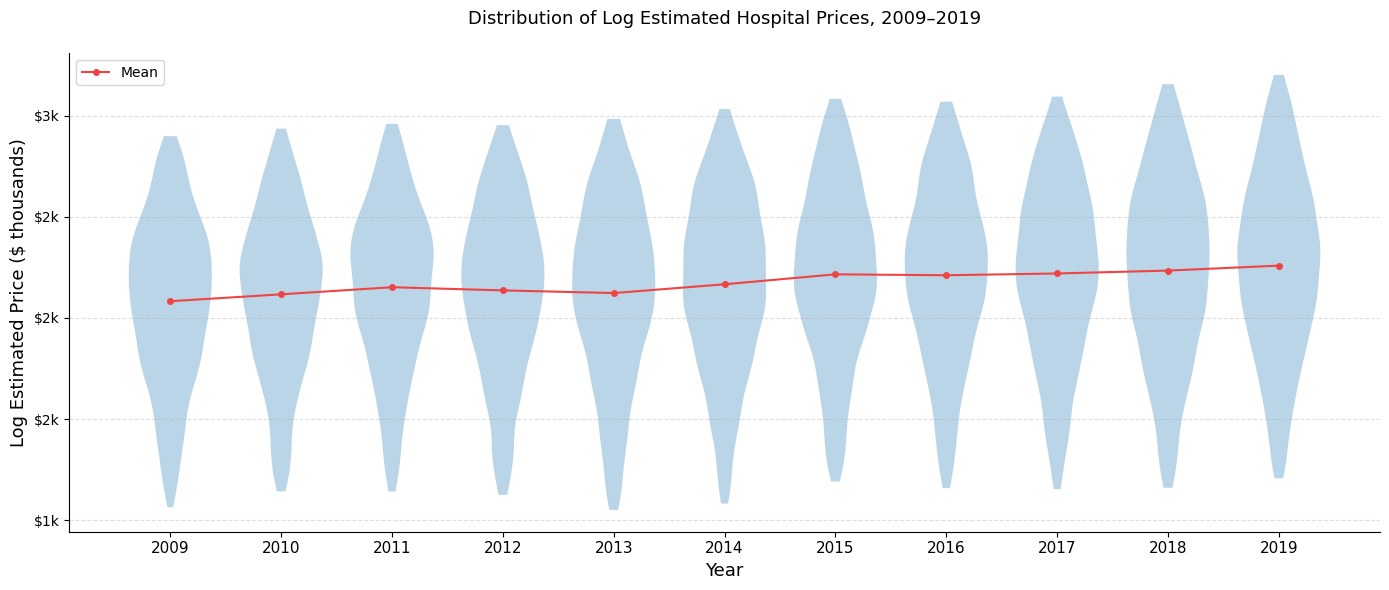

In [6]:
#Question 4

# Caculuate price
df4 = data[data['year'].between(2009, 2019)].copy()

df4['discount_factor'] = 1 - df4['tot_discounts'] / df4['tot_charges']
 
df4['price_num']   = (
    (df4['ip_charges'] + df4['icu_charges'] + df4['ancillary_charges'])
    * df4['discount_factor']
    - df4['tot_mcare_payment']
)
df4['price_denom'] = df4['tot_discharges'] - df4['mcare_discharges']
df4['price']       = df4['price_num'] / df4['price_denom']


# remove zero / negative prices
df4 = df4.dropna(subset=['price'])
df4 = df4[df4['price'] > 0]                         
 
def remove_outliers(g):
    lo, hi = g['price'].quantile([0.05, 0.95])
    return g[(g['price'] >= lo) & (g['price'] <= hi)]
 
df4 = df4.groupby('year', group_keys=False).apply(remove_outliers)
 
years       = sorted(df4['year'].unique())
price_data  = [np.log(df4.loc[df4['year'] == yr, 'price'].values / 1_000)
               for yr in years]                    
 
fig, ax = plt.subplots(figsize=(14, 6))
 
parts = ax.violinplot(
    price_data,
    positions=list(range(len(years))),
    showmedians=False,
    showextrema=False,
    widths=0.75,
)

means = [np.mean(arr) for arr in price_data]
ax.plot(range(len(years)), means, color='#ef4444', linewidth=1.5,
        marker='o', markersize=4, label='Mean')
ax.legend(fontsize=10)
 
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, fontsize=11)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Log Estimated Price ($ thousands)', fontsize=13)
ax.set_title('Distribution of Log Estimated Hospital Prices, 2009–2019\n',
             fontsize=13)
 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}k'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns_style = dict(top=False, right=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('price_violin_2009_2019.png', dpi=150, bbox_inches='tight')
plt.show()


Question 5

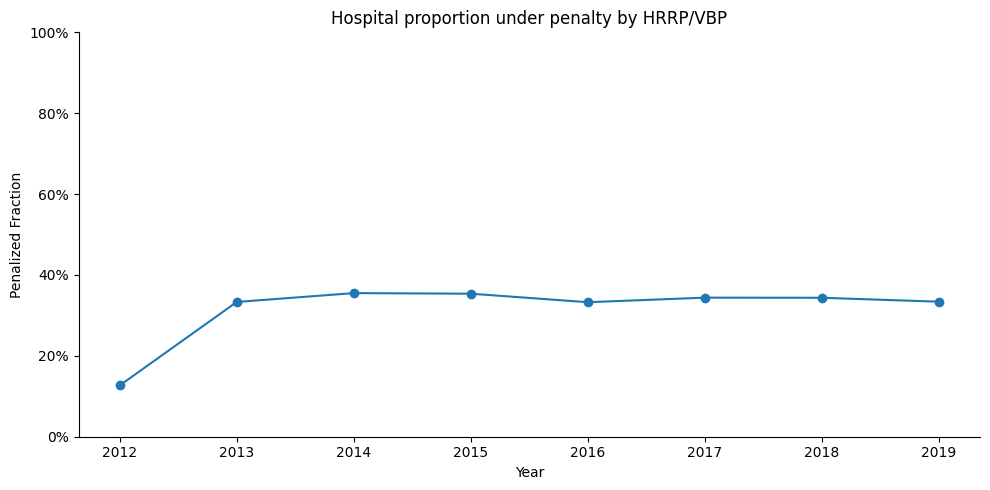

In [7]:
# Question 5
df5 = data[data['year'].between(2012, 2019)].copy()

df5['hvbp_payment'] = df5['hvbp_payment'].fillna(0)
df5['hrrp_payment'] = df5['hrrp_payment'].fillna(0).abs()
df5['penalized']    = (df5['hvbp_payment'] - df5['hrrp_payment']) < 0

summary = (df5.groupby('year')['penalized']
              .mean()
              .reset_index(name='share_penalty'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary['year'], summary['share_penalty'], marker='o')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Year')
ax.set_ylabel('Penalized Fraction')
ax.set_title('Hospital proportion under penalty by HRRP/VBP')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
# Data prep for IV

# Price
data['discount_factor'] = 1 - data['tot_discounts'] / data['tot_charges']
data['price_num']   = (
    (data['ip_charges'] + data['icu_charges'] + data['ancillary_charges'])
    * data['discount_factor']
    - data['tot_mcare_payment']
)
data['price_denom'] = data['tot_discharges'] - data['mcare_discharges']
data['price']       = data['price_num'] / data['price_denom']
 
data = data[data['price'] > 0]
def remove_outliers(g):
    lo, hi = g['price'].quantile([0.01, 0.99])
    return g[(g['price'] >= lo) & (g['price'] <= hi)]


# 2012 Penalty
data['net_penalty'] = data['hvbp_payment'].fillna(0) - data['hrrp_payment'].fillna(0).abs() 

price_2011 = (data[data['year'] == 2011]
              .groupby('provider_number')['price']
              .mean()
              .rename('price_2011'))
 
price_2014 = (data[data['year'] == 2014]
              .groupby('provider_number')['price']
              .mean()
              .rename('price_2014'))
 
# 2012 penalty
pen_2012 = (data[data['year'] == 2012]
            .groupby('provider_number')['net_penalty']
            .mean()
            .rename('net_penalty_2012'))
 
# Pre-2012 averages (2009-2011)
pre = data[data['year'].between(2009, 2011)]
mcare_pre = (pre.groupby('provider_number')['mcare_discharges']
               .mean()
               .rename('avg_mcare_pre'))
mcaid_pre  = (pre.groupby('provider_number')['mcaid_discharges']
               .mean()
               .rename('avg_mcaid_pre'))
beds_pre   = (pre.groupby('provider_number')['beds']
               .mean()
               .rename('avg_beds_pre'))
 
# Merge all into one cross-sectional dataframe
df_iv = (price_2011
         .to_frame()
         .join(price_2014, how='inner')
         .join(pen_2012,   how='inner')
         .join(mcare_pre,  how='inner')
         .join(mcaid_pre,  how='left')
         .join(beds_pre,   how='left')
         .dropna(subset=['price_2011', 'price_2014', 'net_penalty_2012',
                         'avg_mcare_pre']))




# Price change
df_iv['delta_price'] = df_iv['price_2014'] - df_iv['price_2011']
 
#  penalty indicator
df_iv['penalized'] = (df_iv['net_penalty_2012'] != 0).astype(int)
 
lo, hi = df_iv['delta_price'].quantile([0.01, 0.99])
df_iv = df_iv[(df_iv['delta_price'] >= lo) & (df_iv['delta_price'] <= hi)] 

Question 6

In [9]:
#Question 6

# Scale penalty to $thousands for readable coefficients
df_iv['net_penalty_k'] = df_iv['net_penalty_2012'] 
df_iv['avg_mcaid_k']   = df_iv['avg_mcaid_pre']   
 
# ── Three specifications ──────────────────────────────────────────────────────
ols1 = smf.ols('delta_price ~ net_penalty_k',
               data=df_iv).fit(cov_type='HC1')
 
ols2 = smf.ols('delta_price ~ net_penalty_k + avg_beds_pre',
               data=df_iv).fit(cov_type='HC1')
 
ols3 = smf.ols('delta_price ~ net_penalty_k + avg_beds_pre + avg_mcaid_k',
               data=df_iv).fit(cov_type='HC1')
 
# ── Helper: extract coef + stars + SE for one variable ───────────────────────
def fmt(res, var):
    c, se, p = res.params[var], res.bse[var], res.pvalues[var]
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    return f"{c:.4f}{stars}", f"({se:.4f})"
 
# ── Print table ───────────────────────────────────────────────────────────────
models   = [ols1, ols2, ols3]
COL, CW  = 32, 16
 
def row(label, cells):
    return f"{label:<{COL}}" + "".join(f"{c:>{CW}}" for c in cells)
 
print("\n" + "="*(COL + 3*CW))
print("Table 1: OLS — Effect of Net Penalty on Price Change")
print("="*(COL + 3*CW))
print(row("", ["(1)", "(2)", "(3)"]))
print()
 
# Intercept
print(row("Intercept",
          [fmt(m, 'Intercept')[0] for m in models]))
print(row("",
          [fmt(m, 'Intercept')[1] for m in models]))
print()
 
# Net penalty
c_row  = [fmt(m, 'net_penalty_k')[0] for m in models]
se_row = [fmt(m, 'net_penalty_k')[1] for m in models]
print(row("Net penalty ", c_row))
print(row("", se_row))
print()
 
# Bed size (specs 2 & 3 only)
print(row("Avg bed size (pre-2012)",
          ["", fmt(ols2,'avg_beds_pre')[0], fmt(ols3,'avg_beds_pre')[0]]))
print(row("",
          ["", fmt(ols2,'avg_beds_pre')[1], fmt(ols3,'avg_beds_pre')[1]]))
print()
 
# Medicaid discharges (spec 3 only)
print(row("Avg Medicaid disch. (pre-2012)",
          ["", "", fmt(ols3,'avg_mcaid_k')[0]]))
print(row("",
          ["", "", fmt(ols3,'avg_mcaid_k')[1]]))
print()
 
print("-"*(COL + 3*CW))
print(row("N",         [str(int(m.nobs))       for m in models]))
print(row("R-squared", [f"{m.rsquared:.3f}"    for m in models]))
print("="*(COL + 3*CW))
print("Outcome: price change 2011 to 2014.")
print("* p<0.10  ** p<0.05  *** p<0.01")



Table 1: OLS — Effect of Net Penalty on Price Change
                                             (1)             (2)             (3)

Intercept                            244.4727***     227.2617***       110.6192*
                                       (46.4553)       (46.5735)       (57.7236)

Net penalty                           -0.0033***      -0.0032***      -0.0028***
                                        (0.0009)        (0.0009)        (0.0009)

Avg bed size (pre-2012)                                0.0715***       0.0646***
                                                        (0.0088)        (0.0028)

Avg Medicaid disch. (pre-2012)                                         0.0746***
                                                                        (0.0239)

--------------------------------------------------------------------------------
N                                           2417            2417            2409
R-squared                                  0.003  

Question 7

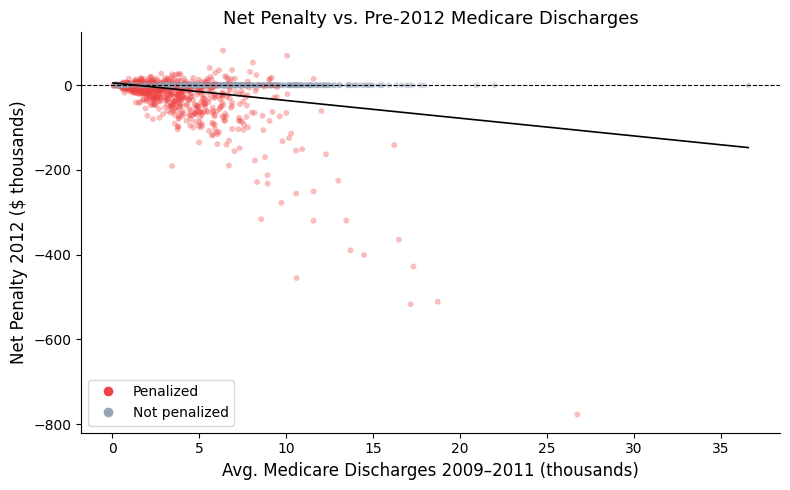

In [10]:
#Question 7
fig, ax = plt.subplots(figsize=(8, 5))
 
colors = df_iv['penalized'].map({1: '#ef4444', 0: '#94a3b8'})
ax.scatter(df_iv['avg_mcare_pre'] / 1_000, df_iv['net_penalty_2012'] / 1_000,
           c=colors, alpha=0.35, s=18, linewidths=0)

x = df_iv['avg_mcare_pre'] / 1_000
y = df_iv['net_penalty_2012'] / 1_000
m, b = np.polyfit(x.fillna(0), y.fillna(0), 1)
ax.plot(sorted(x), [m * xi + b for xi in sorted(x)], color='black', linewidth=1.2, label='Best fit')
 
# Legend proxies
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ef4444',
           markersize=8, label='Penalized'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#94a3b8',
           markersize=8, label='Not penalized'),
]
ax.legend(handles=legend_els, fontsize=10)
 
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Avg. Medicare Discharges 2009–2011 (thousands)', fontsize=12)
ax.set_ylabel('Net Penalty 2012 ($ thousands)', fontsize=12)
ax.set_title('Net Penalty vs. Pre-2012 Medicare Discharges', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('q2_scatter_penalty_mcare.png', dpi=150, bbox_inches='tight')
plt.show()

Question 8

In [11]:
#Question 8
def fmt(res, var):
    c, se, p = res.params[var], res.bse[var], res.pvalues[var]
    stars    = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    decimals = 2 if abs(c) >= 1 else (4 if abs(c) >= 0.01 else 6)
    return f"{c:.{decimals}f}{stars}", f"({se:.{decimals}f})"
 
specs = [
    ('(1)', ''),
    ('(2)', '+ avg_beds_pre'),
    ('(3)', '+ avg_beds_pre + avg_mcaid_pre'),
]
 
# 2 seperate panels
panels = {
    'Panel A: First Stage (Dep. var = Net Penalty)': 'net_penalty_2012',
    'Panel B: Reduced Form (Dep. var = \u0394 Price)': 'delta_price',
}
 
# fit models
models = {
    panel_title: [
        smf.ols(f'{dep} ~ avg_mcare_pre {controls}', data=df_iv).fit(cov_type='HC1')
        for _, controls in specs
    ]
    for panel_title, dep in panels.items()
}
 
# table + formatting
COL, CW = 38, 18
W       = COL + len(specs) * CW
 
def row(label, cells):
    return f"{label:<{COL}}" + "".join(f"{c:>{CW}}" for c in cells)
 
control_rows = [
    ('Bed size control',        [False, True,  True]),
    ('Medicaid disch. control', [False, False, True]),
]
 
print("\n" + "="*W)
print("Table 2: First Stage and Reduced Form")
print("="*W)
print(row("", [label for label, _ in specs]))
 
for panel_title, res_list in models.items():
    print(f"\n{panel_title}")
 
    # Intercept
    print(row("Intercept",       [fmt(r, 'Intercept')[0] for r in res_list]))
    print(row("",                [fmt(r, 'Intercept')[1] for r in res_list]))
    print()
 
    # Instrument: avg_mcare_pre
    print(row("Avg Medicare disch. (pre-2012)", [fmt(r, 'avg_mcare_pre')[0] for r in res_list]))
    print(row("",                               [fmt(r, 'avg_mcare_pre')[1] for r in res_list]))
    print()
 
    # Bed size (specs 2 & 3)
    print(row("Avg bed size (pre-2012)",
              ["", fmt(res_list[1], 'avg_beds_pre')[0], fmt(res_list[2], 'avg_beds_pre')[0]]))
    print(row("",
              ["", fmt(res_list[1], 'avg_beds_pre')[1], fmt(res_list[2], 'avg_beds_pre')[1]]))
    print()
 
    # Medicaid discharges (spec 3 only)
    print(row("Avg Medicaid disch. (pre-2012)",
              ["", "", fmt(res_list[2], 'avg_mcaid_pre')[0]]))
    print(row("",
              ["", "", fmt(res_list[2], 'avg_mcaid_pre')[1]]))
    print()
 
    print("-"*W)
    print(row("N",         [str(int(r.nobs))    for r in res_list]))
    print(row("R-squared", [f"{r.rsquared:.3f}" for r in res_list]))
 
print("="*W)
print("* p<0.10  ** p<0.05  *** p<0.01")



Table 2: First Stage and Reduced Form
                                                     (1)               (2)               (3)

Panel A: First Stage (Dep. var = Net Penalty)
Intercept                                      5865.15**         5862.85**          5325.42*
                                               (2809.91)         (2813.16)         (2774.77)

Avg Medicare disch. (pre-2012)                  -4.18***          -4.19***          -4.63***
                                                  (0.93)            (0.93)            (0.99)

Avg bed size (pre-2012)                                             0.0343         -0.006419
                                                                  (0.0934)        (0.131085)

Avg Medicaid disch. (pre-2012)                                                        1.34**
                                                                                      (0.54)

-------------------------------------------------------------------------

Question 9

In [12]:
#Question 9
def fmt(c, se, p):
    stars    = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    decimals = 2 if abs(c) >= 1 else (4 if abs(c) >= 0.01 else 6)
    return f"{c:.{decimals}f}{stars}", f"({se:.{decimals}f})"
 
#  Three specifications 
specs = [
    ('(1)', []),
    ('(2)', ['avg_beds_pre']),
    ('(3)', ['avg_beds_pre', 'avg_mcaid_pre']),
]
 
endog      = 'net_penalty_2012'
instrument = 'avg_mcare_pre'
dep        = 'delta_price'
 
# Fit all three IV models 
def run_iv(dep, endog, instrument, controls, df):
    cols = [dep, endog, instrument] + controls
    sub  = df[cols].dropna()
    y    = sub[dep]
    X    = sm.add_constant(sub[controls]) if controls else pd.DataFrame(
               np.ones(len(sub)), index=sub.index, columns=['Intercept'])
    D    = sub[[endog]]
    Z    = sub[[instrument]]
    return IV2SLS(y, X, D, Z).fit(cov_type='robust'), len(sub)
 
models = [(run_iv(dep, endog, instrument, controls, df_iv)) for _, controls in specs]
res_list = [m[0] for m in models]
ns       = [m[1] for m in models]
 
# ── Helper to pull fmt from a result object ───────────────────────────────────
def fmt_var(res, var):
    return fmt(res.params[var], res.std_errors[var], res.pvalues[var])
 
# ── Table layout (consistent with Q6 and Q8) ─────────────────────────────────
COL, CW = 38, 18
W       = COL + len(specs) * CW
 
def row(label, cells):
    return f"{label:<{COL}}" + "".join(f"{c:>{CW}}" for c in cells)
 
print("\n" + "="*W)
print("Table 3: IV (2SLS) — Effect of Net Penalty on Price Change")
print("="*W)
print(row("", [label for label, _ in specs]))
print()
 
# Net penalty (endogenous)
print(row("Net penalty (2012)",  [fmt_var(r, endog)[0] for r in res_list]))
print(row("",                    [fmt_var(r, endog)[1] for r in res_list]))
print()
 
# Bed size (specs 2 & 3)
print(row("Avg bed size (pre-2012)",
          ["", fmt_var(res_list[1], 'avg_beds_pre')[0], fmt_var(res_list[2], 'avg_beds_pre')[0]]))
print(row("",
          ["", fmt_var(res_list[1], 'avg_beds_pre')[1], fmt_var(res_list[2], 'avg_beds_pre')[1]]))
print()
 
# Medicaid discharges (spec 3 only)
print(row("Avg Medicaid disch. (pre-2012)",
          ["", "", fmt_var(res_list[2], 'avg_mcaid_pre')[0]]))
print(row("",
          ["", "", fmt_var(res_list[2], 'avg_mcaid_pre')[1]]))
print()
 
print("-"*W)
print(row("N",         [str(n) for n in ns]))
print("="*W)
print("Robust SE in parentheses.  * p<0.10  ** p<0.05  *** p<0.01")
print(row("R-squared", [f"{r.rsquared:.3f}" for r in res_list]))


Table 3: IV (2SLS) — Effect of Net Penalty on Price Change
                                                     (1)               (2)               (3)

Net penalty (2012)                            -0.005773*         -0.004912          0.001666
                                              (0.003083)        (0.003050)        (0.003688)

Avg bed size (pre-2012)                                          0.0701***         0.0673***
                                                                  (0.0070)          (0.0044)

Avg Medicaid disch. (pre-2012)                                                     0.0839***
                                                                                    (0.0270)

--------------------------------------------------------------------------------------------
N                                                   2417              2417              2409
Robust SE in parentheses.  * p<0.10  ** p<0.05  *** p<0.01
R-squared                               

Question 10

The IV estimate identify local ATE for compliant hospitals, or those whos penalty status was determined before 2012 Medicare value. These are likely to be mid sized hospitals. Very small hospitals with too few Medicare patients will not be penalized regardless of quality while large hospitals with very large medicare populations who are always penalized may not be identified in this instrument. This may be evidenced by the fact that the OLS estimate of -.0033 (Question 6) is smaller than the IV estimate of -.0058 (Question 9) The local ATE could differ from the overall ATE if large hospitals respond differentely to penalites regarding their pricing compared to medium or small hospitals.